In [4]:
# import statements & checking for cuda
import torch
torch.set_float32_matmul_precision('high')
from ddpm.trainer import LitDDPM
from ddpm.unet import Unet
from helpers import first_radio_galaxy_transform_val, proj_hermitian
from torch.utils.data import DataLoader
from dataset.radio_galaxy_dataset.firstgalaxydata import FIRSTGalaxyData

import numpy as np
from ddrm.svd_replacement import Fourier2D_mask, Fourier2D_weight
from pathlib import Path
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd
from matplotlib.colors import LogNorm

device = torch.device('cuda')

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    idx = torch.cuda.current_device()
    print("Current device:", idx)
    print("Name:", torch.cuda.get_device_name(idx))
    x = torch.randn(1, device=f"cuda:{idx}")
    print("Tensor device:", x.device)

import os

/user-environment/env/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
Current device: 0
Name: NVIDIA GH200 120GB
Tensor device: cuda:0


In [5]:
# defining the model

# the image size we use will be 150x150, as set by the pre-trained DDPM
image_size = 150

# define and load the pre-trained DDPM
net = Unet(1, 32, 4, 2, 256).to('cuda')
model = LitDDPM.load_from_checkpoint('/capstor/store/cscs/ska/sk031/last-v5.ckpt', unet=net)

Channel per encoder Depth
[32, 64, 128, 256, 512]


In [7]:
# define the sampling operator used by DDRM

# sampling operator H
mask = torch.from_numpy(np.load('uv_coverages/VLA_mask_150_100steps_uniform.npy'))
weights = torch.from_numpy(np.load('uv_coverages/VLA_mask_150_100steps_natural.npy'))
h1 = Fourier2D_mask(channels=1, img_dim=image_size, S=mask, device=device)
h2 = Fourier2D_weight(channels=1, img_dim=image_size, S=weights, device=device)

# number of DDRM sampling steps
# increase this number to improve the image reconstruction
num_steps = 5000

# for a single input image, we will denoise batch_size times
# increase this number to get more samples
batch_size = 4

# sigma is the amount of noise added to visibility space
sigma_0 = 0.01

# the eta hyperparamt 
eta_A, eta_B, eta_C = 0.85, 1.0, 0.85

In [8]:
# for our test data we choose an out-of-domain image
# however, we need to trim/resize this down to our 150x150 input image size
test_image_file = "/capstor/scratch/cscs/etolley/3c353_gdth.fits"

from astropy.io import fits

with fits.open(test_image_file) as hdul:
    # this image is 512 x 512, rescale to 150x150
    true_image = hdul[0].data.astype(np.float32)
    true_image = true_image[175:175+150,10:160]
assert true_image.shape == (image_size, image_size)

#rescale the input image to go from 0 to 1
shift = np.min(true_image)
scale = np.max(true_image)
true_image = (true_image-shift)/(scale-shift)

In [11]:
# format the true image x_0
x = torch.from_numpy(true_image).reshape(1,image_size, image_size)
x_gpu = x.to(device)
x_0 = x_gpu.unsqueeze(0).repeat(batch_size, 1, 1, 1)

# define the observation y_0
y1_0 = h1.H(x_0)
y1_0 = y1_0 + sigma_0 * proj_hermitian(torch.randn_like(y1_0) * np.sqrt(2))

# do the DDRM sampling
with model.ema.average_parameters():
    model.model.eval()
    x_hat, _ = model.model.sample_ddrm_y0(
        image_size, num_steps, y1_0, x_0.shape[0], h1, sigma_0, eta_A, eta_B, eta_C
    )

# rescale the image estimate x_hat
x_hat = ((x_hat[-1] + 1) / 2).clamp(0, 1)      

Autotune Choices Stats:
{"num_choices": 17, "num_triton_choices": 16, "best_kernel": "triton_mm_96", "best_kernel_desc": "ACC_TYPE='tl.float32', ALLOW_TF32=True, BLOCK_K=32, BLOCK_M=128, BLOCK_N=64, EVEN_K=True, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=3, num_warps=4", "best_time": 0.015104000456631184, "best_triton_pos": 0}
AUTOTUNE mm(102400x32, 32x64)
strides: [32, 1], [1, 32]
dtypes: torch.float32, torch.float32
  triton_mm_96 0.0151 ms 100.0% ACC_TYPE='tl.float32', ALLOW_TF32=True, BLOCK_K=32, BLOCK_M=128, BLOCK_N=64, EVEN_K=True, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=3, num_warps=4
  triton_mm_90 0.0156 ms 96.9% ACC_TYPE='tl.float32', ALLOW_TF32=True, BLOCK_K=32, BLOCK_M=64, BLOCK_N=64, EVEN_K=True, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=2, num_warps=4
  triton_mm_97 0.0156 ms 96.9% ACC_TYPE='tl.float32', ALLOW_TF32=True, BLOCK_K=32, BLOCK_M=128, BLOCK_N=64, EVEN_K=True, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=4, num_warps=8
  triton_mm_94 0.0157 ms 96.1% ACC_TY

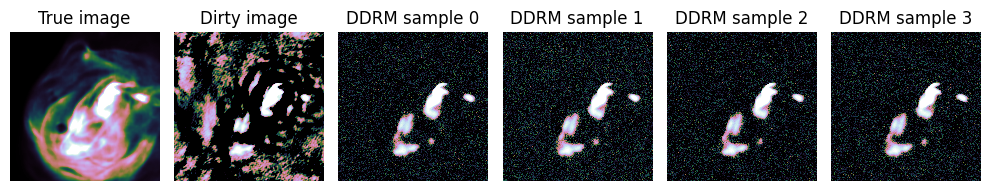

In [14]:
#make plots
fig, ax = plt.subplots(1,2+batch_size, figsize=(10, 3))
for a in ax.flatten(): a.set_axis_off()
plt.tight_layout()

x_dirty = h1.H_pinv(y1_0).reshape(batch_size,image_size,image_size).cpu()

cnorm = colors.SymLogNorm(linthresh=0.01,vmin=0,vmax=.1)
#plt.subplots_adjust(left=0.06, right=0.99, top=0.99, bottom=0.1, wspace=0.0, hspace = 0.1)
ax[0].imshow(x.reshape(image_size,image_size),norm=cnorm,cmap = "cubehelix")
ax[1].imshow(x_dirty[0,...],norm = cnorm,cmap = "cubehelix")
ax[0].set_title("True image")
ax[1].set_title("Dirty image")
for b in range(batch_size):
    ax[b+2].imshow(x_hat[b,...].reshape(image_size,image_size), norm = cnorm,cmap = "cubehelix")
    ax[b+2].set_title("DDRM sample {0}".format(b))
plt.show()